# TP2 - Informe tecnico

Sistema de Deteccion y Clasificacion de Razas de Perros — IA 5.2 Computer Vision.

## Equipo
- Alumno 1 : Juan Andrés Morales
- Alumno 2 : Genaro Canciani

# Librerías

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path
from PIL import Image
import difflib
import os

## 1. Explicacion completa del pipeline

TO-DO: describir el flujo Embeddings -> Busqueda por similitud -> Clasificacion -> Deteccion -> Pipeline completo,
y como se integran los componentes (base vectorial, modelos, YOLO, aplicacion Gradio).

## 2. Dataset

TO-DO: distribucion de clases, cantidad de imagenes por raza, definicion de splits
(train/valid/test) y conjunto independiente de evaluacion.

## 2.1 Análisis de balance

Total de imágenes en TODO el dataset: 9346

--- Cantidad total de imágenes por partición ---


,Partición,Cantidad
0,test,700
1,train,7946
2,valid,700



--- Verificación de balanceo en particiones Valid y Test ---


,Partición,Minimo,Maximo,Promedio,Desvio_Estandar
0,test,10,10,10.0,0.0
1,valid,10,10,10.0,0.0


* Nota: Si el 'Mínimo' y el 'Máximo' son iguales (y el desvío es 0), significa que estas particiones están perfectamente balanceadas por clase.



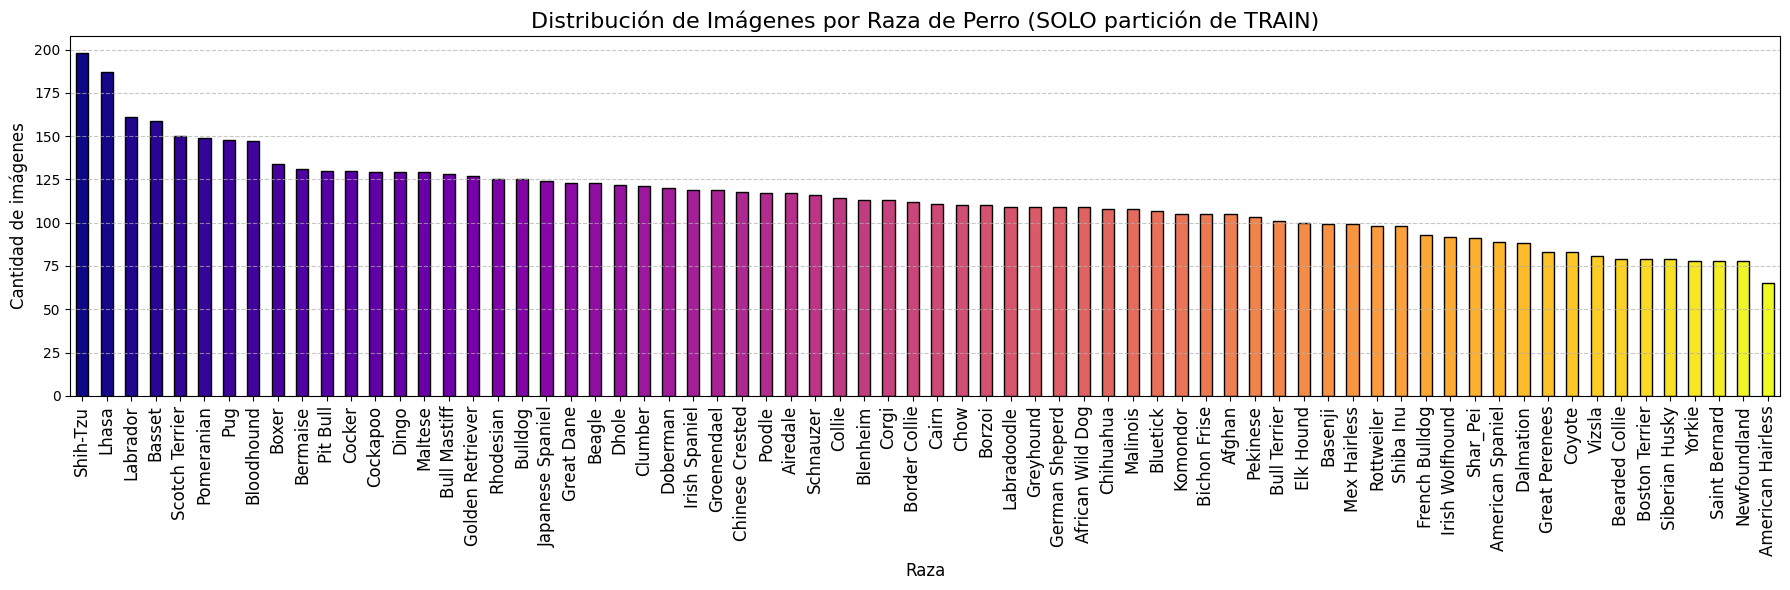

In [2]:
# Definimos las rutas y particiones
dataset_path = Path('data/dataset')
splits = ['train', 'valid', 'test']

data = []

# Recorremos cada partición y cada raza para contar las imágenes
for split in splits:
    split_dir = dataset_path / split
    if not split_dir.exists():
        continue
        
    for breed_dir in split_dir.iterdir():
        if breed_dir.is_dir():
            count = sum(1 for f in breed_dir.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png'])
            data.append({
                'Partición': split, 
                'Raza': breed_dir.name, 
                'Cantidad': count
            })

df = pd.DataFrame(data)

# 1. Total de imágenes 
print(f"Total de imágenes en TODO el dataset: {df['Cantidad'].sum()}\n")

# 2. Cantidad total de imágenes por partición
print("--- Cantidad total de imágenes por partición ---")
display(df.groupby('Partición')['Cantidad'].sum().reset_index())

# 3. Verificar balanceo en Valid y Test
print("\n--- Verificación de balanceo en particiones Valid y Test ---")
val_test_df = df[df['Partición'].isin(['valid', 'test'])]
balance_check = val_test_df.groupby('Partición')['Cantidad'].agg(
    Minimo='min', 
    Maximo='max', 
    Promedio='mean', 
    Desvio_Estandar='std'
).reset_index()

display(balance_check)
print("* Nota: Si el 'Mínimo' y el 'Máximo' son iguales (y el desvío es 0), significa que estas particiones están perfectamente balanceadas por clase.\n")

# 4. Gráfico de distribución SOLO para TRAIN (¡Ahora con colores!)
train_df = df[df['Partición'] == 'train']
train_counts = train_df.set_index('Raza')['Cantidad'].sort_values(ascending=False)

# Generamos un gradiente de colores (prueba 'viridis', 'plasma', 'inferno' o 'rainbow')
colores = plt.cm.plasma(np.linspace(0, 1, len(train_counts)))

plt.figure(figsize=(18, 6))
train_counts.plot(kind='bar', color=colores, edgecolor='black')
plt.title('Distribución de Imágenes por Raza de Perro (SOLO partición de TRAIN)', fontsize=16)
plt.xlabel('Raza', fontsize=12)
plt.ylabel('Cantidad de imágenes', fontsize=12)
plt.xticks(rotation=90, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Como se observa en el trabajo de exploración de arriba, tanto en el conjunto de validación como en el de prueba la cantidad de imágenes de cada clase está fija en 10. Sin embargo, en el dataset de train el desbalance es claro. La clase que más imágenes tiene cuenta con alrededor de 200 mientras que la que menos tiene apenas más de 50. Sabiendo esto, definiremos en el futuro un método de balanceo para armonizar el entrenamiento de los modelos. 

## 2.2 Análisis de resolución

In [3]:
# Buscamos TODAS las imágenes JPG en el dataset completo (train, valid, test)
dataset_path = Path('data/dataset')
all_images = list(dataset_path.rglob('*.jpg'))

if not all_images:
    print("No se encontraron imágenes en data/dataset")
else:
    # Usamos un 'set' directamente. Es más rápido y evita guardar miles de repetidos en memoria.
    tamaños_unicos = set()
    
    print(f"Analizando {len(all_images)} imágenes... Por favor espera un momento.")
    
    for img_path in all_images:
        with Image.open(img_path) as img:
            tamaños_unicos.add(img.size) # img.size devuelve (ancho, alto)

    print("-" * 50)
    print(f"Se analizaron TODAS las {len(all_images)} imágenes con éxito.")
    
    if len(tamaños_unicos) == 1:
        ancho, alto = list(tamaños_unicos)[0]
        print(f"El dataset es uniforme, Todas las imágenes tienen EXACTAMENTE la misma resolución: {ancho}x{alto} píxeles.")
    else:
        print(f"Las resoluciones varían. Se encontraron {len(tamaños_unicos)} tamaños distintos en todo el dataset.")
        print("Ejemplos de resoluciones encontradas (Ancho x Alto):")
        # Imprimimos hasta 10 resoluciones distintas como ejemplo
        for res in list(tamaños_unicos)[:10]:
            print(f" - {res[0]}x{res[1]}")

Analizando 9346 imágenes... Por favor espera un momento.
--------------------------------------------------
Se analizaron TODAS las 9346 imágenes con éxito.
El dataset es uniforme, Todas las imágenes tienen EXACTAMENTE la misma resolución: 224x224 píxeles.


La resolución de las imágenes es una bastante estándard, por lo que hacer un resize agresivo es innecesario y, por ende, se decide trabajar en las diferentes etapas del proyecto con la misma resolución. 

## 2.3 Observación de imágenes 

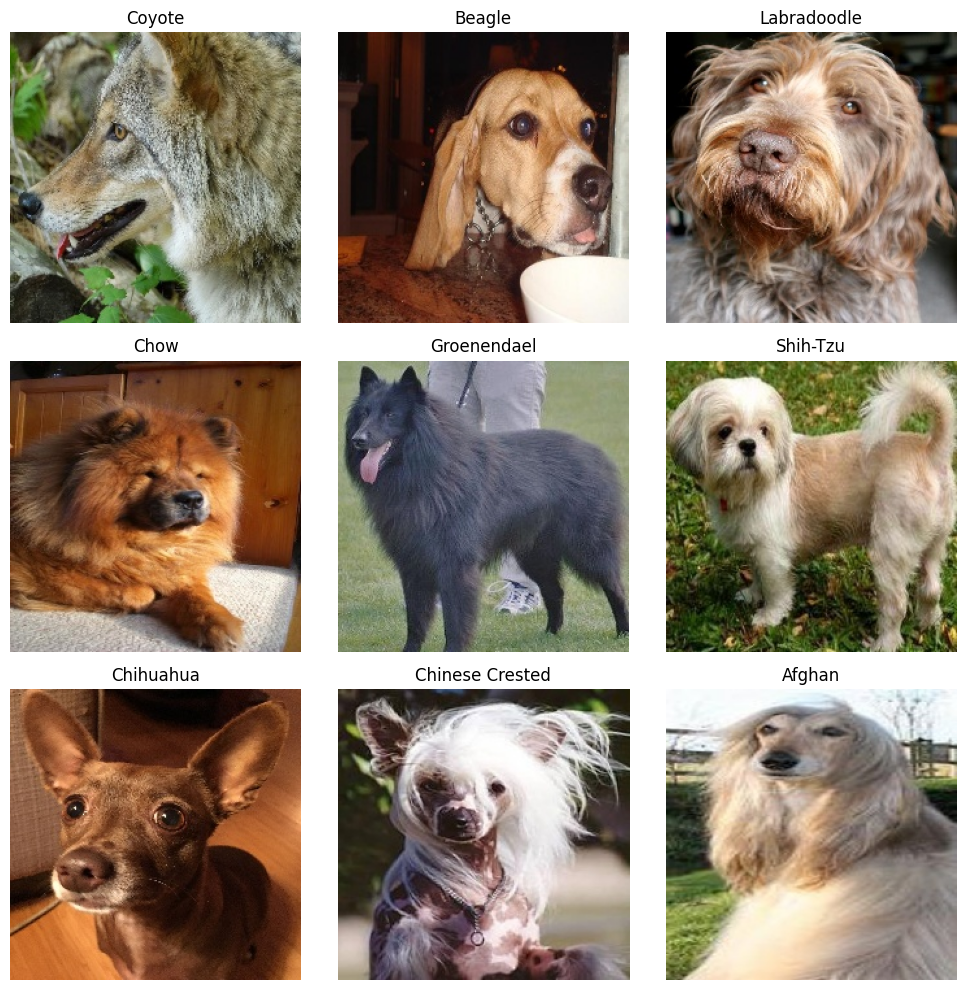

In [4]:
if not all_images:
    print("La variable 'all_images' está vacía. Ejecuta la celda anterior primero.")
else:
    # Agrupamos las rutas por raza leyendo el nombre de la carpeta padre
    imagenes_por_raza = {}
    for img_path in all_images:
        raza = img_path.parent.name
        if raza not in imagenes_por_raza:
            imagenes_por_raza[raza] = []
        imagenes_por_raza[raza].append(img_path)

    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()

    # Elegimos 9 razas distintas completamente al azar
    razas_muestra = random.sample(list(imagenes_por_raza.keys()), min(9, len(imagenes_por_raza)))

    for i, raza in enumerate(razas_muestra):
        # Elegimos una imagen al azar de esa raza
        img_path = random.choice(imagenes_por_raza[raza])
        
        img = Image.open(img_path)
        axes[i].imshow(img)
        
        # Formateamos el nombre para que quede lindo en el título
        nombre_raza = raza.replace('_', ' ').title()
        axes[i].set_title(nombre_raza, fontsize=12)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()


## 3. Preprocesamiento

TO-DO: tecnicas aplicadas (resize, normalizacion, data augmentation, filtrado) y su justificacion.

## 4. Justificacion de los modelos elegidos

TO-DO: modelo de embeddings baseline (Etapa 1), ResNet18 fine-tuned y CNN custom (Etapa 2),
YOLO (Etapa 3). Analizar trade-offs: precision, velocidad de inferencia, consumo de memoria
y complejidad computacional.

Para la **etapa 1**, el modelo elegido es *ResNet34*, entrenado originalmente en ImageNet. Se considera que el mismo cuenta con la capacidad de generar incrustaciones ricas en información por su estructura y profundidad, además de contar con un entrenamiento muy robusto con el dataset mencionado anteriormente. Se selecciona este modelo y no otro de la familia ResNet por dos razones: 
1. La profundidad de esta red nos da un balance perfecto entre performance y calidad de las representaciones vectoriales. Usar un modelo más grande hubiera generado más latencia a la hora de la carga del modelo,empeorando así la experiencia de usuario por una ganacia irrelevante de precisión. 
2. Como la app trabaja con diferentes modelos de embeddings, la mayoría que generar representaciones de 512 dimensiones, Resnet34 da como salida exactamente esa cantidad lo que nos permite mantener la congruencia dentro de la base de datos. 


## 5. Proceso de entrenamiento e hiperparametros

TO-DO: proceso de fine-tuning, hiperparametros utilizados (learning rate, batch size, epochs,
optimizador, scheduler), curvas de entrenamiento.

## 6. Resultados obtenidos

### Etapa 1: Búsqueda por Similitud (Mean NDCG@10)
Para la etapa de similitud de imágenes, se utilizó un modelo **ResNet34** pre-entrenado en ImageNet (omitiendo su capa de clasificación final) para extraer embeddings de 512 dimensiones de cada imagen. Todas las imágenes del conjunto de entrenamiento fueron indexadas en una base de datos vectorial PostgreSQL (`pgvector`). Luego, se evaluó cada imagen del conjunto de prueba solicitando al sistema los 10 vecinos más cercanos (Top-10).

**Resultado General:** 
El sistema logró un desempeño sobresaliente en la gran mayoría de las razas, obteniendo scores de **NDCG@10 superiores a 0.90**, lo que demuestra que la morfología de las razas caninas ya se encuentra profundamente codificada en los pesos de los modelos pre-entrenados estándar de visión artificial.

**Justificación y Análisis de Anomalías:**
Al desglosar los resultados por raza, se observó que la clase `Bulldog` obtuvo el peor rendimiento de todo el dataset, siendo la única con un score de NDCG@10 por debajo de 0.80 (aprox. 0.67). 

Para justificar este desplome en la métrica, se realizó un análisis cualitativo (graficando los errores de recuperación) y un análisis cuantitativo (t-SNE 3D y Clustering con K-Means). El estudio reveló que **el algoritmo no está fallando**, sino que existe un grave problema de **contaminación de datos (Data Noising)** en el dataset provisto. Se descubrió que decenas de ejemplares de la raza *Boston Terrier* fueron incorrectamente etiquetados y ubicados dentro de la carpeta *Bulldog*. 

Como consecuencia, cuando se consultaba por la foto de un Boston Terrier (etiquetado erróneamente como Bulldog), el modelo ResNet34 identificaba correctamente la morfología del animal y recuperaba fotos de otros Boston Terriers de la base de datos. Sin embargo, la función de evaluación penalizaba fuertemente estos aciertos porque la etiqueta oficial (`Bulldog`) no coincidía con la raza devuelta (`Boston Terrier`). Esto demuestra la eficacia del modelo para agrupar imágenes por similitud visual, e ilustra cómo el ruido en el Ground Truth puede distorsionar dramáticamente las métricas de evaluación.

---
**TO-DO:**
- Etapa 2: accuracy, precision, recall, specificity, F1, matriz de confusion.


## 7. Comparacion entre enfoques

TO-DO: busqueda por similitud vs clasificacion supervisada; ResNet18 fine-tuned vs CNN custom.

## 8. Problemas encontrados y soluciones implementadas

### 8.1 Cast de tipo en pgvector

**Problema:** Al ejecutar la búsqueda por similitud con PostgreSQL + pgvector, se obtenía el error:

operator does not exist: vector <=> double precision[] HINT: No operator matches
the given name and argument types. You might need to add explicit type casts.

Esto ocurre porque pgvector requiere que el embedding de consulta sea explícitamente del tipo `vector` para usar el operador de distancia coseno (`<=>`).

**Solución:** Se modificó `src/lib/storage/pgvector_store.py` agregando el cast explícito `::vector` en la consulta SQL:

```sql
ORDER BY embedding <=> %s::vector

### 8.2 Indexado fuera del contenedor Docker
**Problema:** Al trabajar con Docker para la evaluación final (docker compose build && docker compose up), la carpeta scripts/ no está copiada dentro de la imagen (el Dockerfile solo copia src/). Como consecuencia, no es posible ejecutar python scripts/build_index.py dentro del contenedor para indexar el dataset.

Además, si el indexado se realiza desde la máquina local (Windows), los paths guardados en pgvector son rutas absolutas como:
c:\Users\...\data\dataset\train\Beagle\085.jpg

Dentro del contenedor estas rutas no existen. El backend está en /app, donde el dataset se monta en /app/data/dataset/.... Como file_to_public_url() no puede relativizar las rutas de Windows contra /app/data, el campo url de los vecinos queda null y las Top-K imágenes no se muestran en la interfaz.

**Solución:** Se agregó el volumen `./scripts:/app/scripts` en `docker-compose.yml` para montar la carpeta `scripts/` dentro del contenedor. Luego se reindexó ejecutando:

docker compose exec backend python scripts/build_index.py --split train

De esta forma los paths guardados en la base vectorial son del estilo /app/data/dataset/train/Beagle/085.jpg, que el backend resuelve correctamente contra DATA_PATH=data.

## 9. Modificaciones fuera de las funciones indicadas

1. **`src/lib/storage/pgvector_store.py`** (línea 121): Se agregó el cast `::vector` en la consulta SQL del método `search()` para resolver un error de tipos en pgvector. Sin este cambio, el operador `<=>` no funciona correctamente. Es una corrección mínima sobre infraestructura provista por la cátedra.

2. **`docker-compose.yml`** (servicio `backend`, sección `volumes`): Se agregó `./scripts:/app/scripts` para poder ejecutar `build_index.py` dentro del contenedor Docker. Esto es necesario porque `scripts/` no está copiado en la imagen Docker (el Dockerfile solo copia `src/`), y el indexado debe hacerse dentro del contenedor para que los paths del dataset sean consistentes con la estructura de archivos del backend en producción.